# 01 — Izhikevich and Hodgkin-Huxley single-neuron tutorials

This notebook explores the fundamental building blocks of biophysical modeling: single-compartment membrane models. We focus on two canonical representations:

1. **Izhikevich Model**: A computationally efficient 2D system capturing a vast array of firing patterns (RS, FS, LTS).
2. **Hodgkin-Huxley (HH) Model**: The gold standard for biophysical realism, modeling individual Na+ and K+ channel kinetics.

### Unit Scaling and Precision
- Canonical Izhikevich updates are **ms-scaled**. We explicitly avoid $dt$ in seconds to maintain the original phenomenological properties.
- Input drive `I` is treated as a dimensionless current-like value, which requires calibration before mapping to SI units.

Scientific status: **tutorial exploratory, not biological truth**.


In [1]:
import os, sys, math, json
from pathlib import Path
import numpy as np

SMOKE_MODE = True
SEED = 123
np.random.seed(SEED)

# Allow running from repo root or from the tutorials directory.
ROOT = Path.cwd()
if not (ROOT / "src" / "jbiophysic").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
print("ROOT", ROOT)
print("SMOKE_MODE", SMOKE_MODE, "SEED", SEED)


In [2]:
from jbiophysic.cells.izhikevich import REGULAR_SPIKING, FAST_SPIKING, LOW_THRESHOLD_SPIKING, simulate_izhikevich
from jbiophysic.cells.hh import simulate_hh


## Izhikevich regular-spiking neuron


In [3]:
dt_ms = 0.1
T_ms = 300.0 if SMOKE_MODE else 1000.0
time = np.arange(int(T_ms/dt_ms)) * dt_ms
I = np.zeros_like(time, dtype=np.float32)
I[(time >= 50) & (time <= 250)] = 10.0  # native Izhikevich current-like units, not nA
v, u, spikes = simulate_izhikevich(I, params=REGULAR_SPIKING, dt_ms=dt_ms)
print({"finite": bool(np.isfinite(np.asarray(v)).all()), "spikes": int(np.asarray(spikes).sum()), "v_min": float(np.min(v)), "v_max": float(np.max(v))})


{'finite': True, 'spikes': 5, 'v_min': -76.77350616455078, 'v_max': 27.262067794799805}


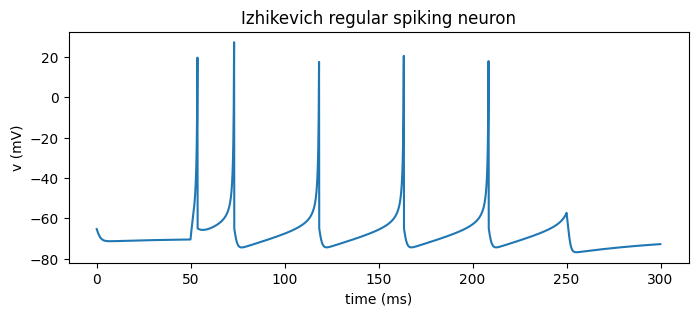

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,3))
plt.plot(time, np.asarray(v))
plt.title("Izhikevich regular spiking neuron")
plt.xlabel("time (ms)")
plt.ylabel("v (mV)")
plt.show()


## PV-like fast spiking and SST-like low-threshold placeholders


In [5]:
for name, params, drive in [("PV/FS", FAST_SPIKING, 8.0), ("SST/LTS", LOW_THRESHOLD_SPIKING, 8.0)]:
    I2 = np.zeros_like(time, dtype=np.float32)
    I2[(time >= 50) & (time <= 250)] = drive
    vv, uu, ss = simulate_izhikevich(I2, params=params, dt_ms=dt_ms)
    print(name, {"spikes": int(np.asarray(ss).sum()), "finite": bool(np.isfinite(np.asarray(vv)).all())})


PV/FS {'spikes': 20, 'finite': True}
SST/LTS {'spikes': 15, 'finite': True}


## Hodgkin-Huxley current-balance neuron


In [6]:
hh_dt_ms = 0.025
hh_T_ms = 25.0 if SMOKE_MODE else 120.0
hh_time = np.arange(int(hh_T_ms/hh_dt_ms)) * hh_dt_ms
I_app = np.zeros_like(hh_time, dtype=np.float32)
I_app[(hh_time >= 10) & (hh_time <= 60)] = 10.0  # uA/cm^2
V_hh, gates = simulate_hh(I_app, dt_ms=hh_dt_ms)
print({"finite": bool(np.isfinite(np.asarray(V_hh)).all()), "V_min": float(np.min(V_hh)), "V_max": float(np.max(V_hh)), "gates_shape": tuple(gates.shape)})


{'finite': True, 'V_min': -75.14073944091797, 'V_max': 40.927635192871094, 'gates_shape': (3, 1000)}


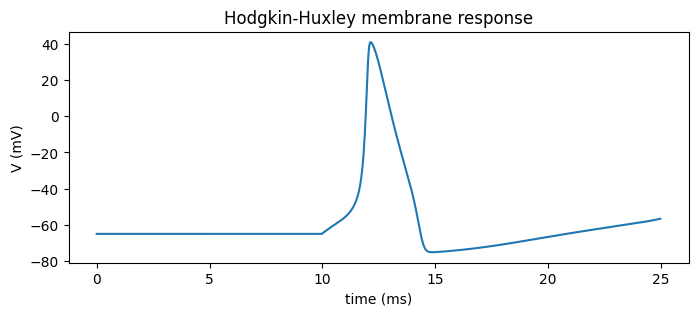

In [7]:
plt.figure(figsize=(8,3))
plt.plot(hh_time, np.asarray(V_hh))
plt.title("Hodgkin-Huxley membrane response")
plt.xlabel("time (ms)")
plt.ylabel("V (mV)")
plt.show()


## Validation summary

The Izhikevich and HH examples are finite smoke tests.  They do not prove a biological mechanism; they establish numerically usable single-neuron primitives for later circuit tutorials.
